# PyMC-16 : Processus Gaussiens et frontières non linéaires

**Navigation** : [Index](../README.md) | [<< PyMC-15](PyMC-15-Recommenders.ipynb) | [PyMC-17 >>](PyMC-17-Kalman-Filter.ipynb)

**Equivalent Infer.NET** : [Infer-16-Sparse-Gaussian-Process](../Infer/Infer-16-Sparse-Gaussian-Process.ipynb)

**Serie** : Programmation Probabiliste avec PyMC (16 / parite Infer.NET, #4956)
**Duree estimee** : 55 minutes
**Prerequis** : [PyMC-9-Classification](PyMC-9-Classification.ipynb) (régression logistique), [PyMC-2-Gaussian-Mixtures](PyMC-2-Gaussian-Mixtures.ipynb)

---

## Objectifs

- Comprendre le **processus gaussien** comme une distribution sur des fonctions
- Construire un prior via un **noyau** (kernel RBF / squared-exponential)
- Implementer la **classification GP** (modèle logistique / lien logit) sur des données non linéairement séparables
- Visualiser la **frontière de decision** non linéaire et les zones d'incertitude
- Comparer l'effet de la **longueur de corrélation** (length-scale) du noyau

> Ce notebook est le port Python (PyMC) du notebook Infer.NET [Infer-16-Sparse-Gaussian-Process](../Infer/Infer-16-Sparse-Gaussian-Process.ipynb). L'API PyMC (`pm.gp`) diffère de l'API Infer.NET (`SparseGP`) mais le paradigme — un prior gaussien sur les fonctions, bruité puis seuillée pour la classification — est identique.


## 1. Le processus gaussien : un prior sur des fonctions

Un **processus gaussien (GP)** est une distribution de probabilité sur des fonctions : pour tout ensemble fini de points, les valeurs de la fonction suivent conjointement une loi gaussienne. Le GP est specifie par sa fonction **moyenne** $m(x)$ (souvent nulle) et sa fonction de **covariance** $k(x, x')$ — le **noyau**.

Le noyau le plus courant est le **RBF** (squared-exponential) :

$$k(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2 \, \ell^2}\right)$$

ou $\ell$ est la **longueur de corrélation** (length-scale). Deux points proches ($\|x-x'\| \ll \ell$) sont fortement corrélés ; deux points éloignés ($\|x-x'\| \gg \ell$) sont quasi-indépendants. Le noyau mesure donc la **similitude** entre points.

In [1]:
# Imports : PyMC (pm.gp), ArviZ, NumPy, Matplotlib.
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="PyTensor could not link to a BLAS")  # advisory pytensor (#3436 path-leak)

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")
print("PyMC pret pour les processus gaussiens.")


PyMC 5.28.5, ArviZ 0.23.4
PyMC pret pour les processus gaussiens.


### Noyau RBF : covariance entre points du plan

La table ci-dessous montre la covariance RBF ($\ell = 1$) entre quelques points du plan — proche de 1 quand les points coïncident, decroissant vers 0 avec la distance.

In [2]:
# Noyau RBF (squared-exponential) : k(x,x') = exp(-||x-x'||^2 / (2*ls^2))
def rbf_kernel(x1, x2, ls=1.0):
    diff = x1[:, None, :] - x2[None, :, :]
    return np.exp(-np.sum(diff ** 2, axis=2) / (2 * ls ** 2))

# Probe : covariance entre quelques points du plan.
probes = np.array([[0.0, 0.0], [0.5, 0.0], [1.0, 0.0], [0.0, 1.0], [2.0, 0.0]])
K = rbf_kernel(probes, probes, ls=1.0)
print("Covariance RBF (ls=1) entre probes :")
print(np.round(K, 3))
print("\nSur la diagonale (meme point) = 1.0 ; la covariance decroit avec la distance.")


Covariance RBF (ls=1) entre probes :
[[1.    0.882 0.607 0.607 0.135]
 [0.882 1.    0.882 0.535 0.325]
 [0.607 0.882 1.    0.368 0.607]
 [0.607 0.535 0.368 1.    0.082]
 [0.135 0.325 0.607 0.082 1.   ]]

Sur la diagonale (meme point) = 1.0 ; la covariance decroit avec la distance.


### Fonctions tirees du prior GP

En 1D, on peut tirer des fonctions concrètes du prior GP en échantillonnant une gaussienne multivariée de covariance $K$. Ces fonctions sont **lisses** (le noyau RBF est infiniment différentiable) et oscillent a une échelle $\ell$.

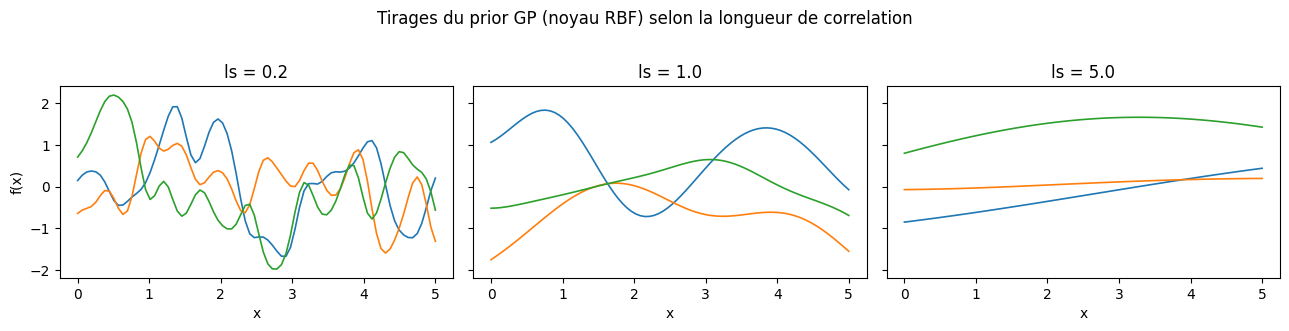

In [3]:
# Trois longueurs de correlation : ls=0.2 (tres wiggly), 1.0 (modere), 5.0 (tres lisse).
x_grid = np.linspace(0, 5, 80)[:, None]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, ls in zip(axes, [0.2, 1.0, 5.0]):
    K = rbf_kernel(x_grid, x_grid, ls=ls)
    # 3 tirages du prior : gaussienne multivariee de covariance K.
    samples = rng.multivariate_normal(np.zeros(len(x_grid)), K, size=3)
    for s in samples:
        ax.plot(x_grid, s, lw=1.2)
    ax.set_title(f"ls = {ls}")
    ax.set_xlabel("x")
axes[0].set_ylabel("f(x)")
fig.suptitle("Tirages du prior GP (noyau RBF) selon la longueur de correlation", y=1.02)
plt.tight_layout()
plt.show()


## 2. Le dataset « donut » : deux classes non linéairement séparables

On construit un jeu de données en forme d'anneau : un **disque intérieur** (classe 0) entouré d'un **anneau extérieur** (classe 1). Aucun hyperplan (frontière linéaire) ne peut séparer ces deux classes — c'est précisément la situation ou un classifieur linéaire (régression logistique) échoue et ou un GP brille.

Dataset donut : 16 points (8 interieurs classe 0, 8 exterieurs classe 1).
Rayon interieur moyen : 0.43
Rayon exterieur moyen : 1.35


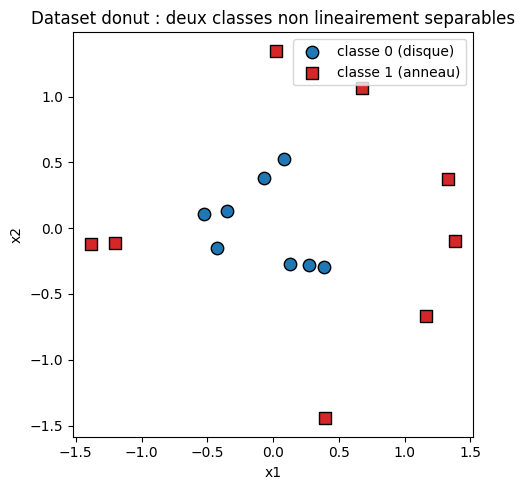

In [4]:
# Dataset "donut" : disque interieur (classe 0) + anneau exterieur (classe 1).
# Memes parametres que le notebook Infer-16 (seed 7) pour un equivalent reproductible.
rng = np.random.default_rng(7)
inputs_inner = []
for _ in range(8):
    r = 0.30 + 0.30 * rng.random()
    t = 2.0 * np.pi * rng.random()
    inputs_inner.append([r * np.cos(t), r * np.sin(t)])
inputs_outer = []
for _ in range(8):
    r = 1.20 + 0.30 * rng.random()
    t = 2.0 * np.pi * rng.random()
    inputs_outer.append([r * np.cos(t), r * np.sin(t)])

X_donut = np.array(inputs_inner + inputs_outer)
y_donut = np.array([0] * 8 + [1] * 8)

print(f"Dataset donut : {len(X_donut)} points ({8} interieurs classe 0, {8} exterieurs classe 1).")
print(f"Rayon interieur moyen : {np.linalg.norm(np.array(inputs_inner), axis=1).mean():.2f}")
print(f"Rayon exterieur moyen : {np.linalg.norm(np.array(inputs_outer), axis=1).mean():.2f}")

plt.figure(figsize=(5, 5))
plt.scatter(X_donut[y_donut == 0, 0], X_donut[y_donut == 0, 1], c="C0", s=80, label="classe 0 (disque)", edgecolors="k")
plt.scatter(X_donut[y_donut == 1, 0], X_donut[y_donut == 1, 1], c="C3", s=80, marker="s", label="classe 1 (anneau)", edgecolors="k")
plt.gca().set_aspect("equal")
plt.legend(loc="upper right")
plt.title("Dataset donut : deux classes non lineairement separables")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()


## 3. Modèle : classification GP logistique (lien logit)

On pose un **prior GP** sur la fonction de score $f(x)$, de moyenne nulle et de covariance RBF. La classification est **logistique** (lien **logit**) : la probabilité de la classe 1 est $\sigma(f(x)) = 1/(1+e^{-f(x)})$ (sigmoïde logistique).

> **Ne pas confondre avec le probit.** Le lien *probit* utilise $p = \Phi(f)$ (CDF de la loi normale centrée réduite), qui est le lien du jumeau Infer.NET (`GaussianFromMeanAndVariance > 0`, « bruit gaussien seuillé à 0 »). Logit ($\sigma$) et probit ($\Phi$) sont numériquement proches mais distincts (Rasmussen & Williams 2006, §3.9).

Le paramètre critique est la **longueur de corrélation** $\ell$ : on lui met un prior faible (`LogNormal`) pour que le GP l'apprenne depuis les données plutot que de le fixer arbitrairement.

$$f \sim \mathcal{GP}(0, k_{\text{RBF}}), \qquad y_i \sim \text{Bernoulli}(\sigma(f(x_i)))$$

PyMC fournit `pm.gp.Latent` pour un GP sur une variable latente (non conjuguee — NUTS requis, contrairement a la régression GP conjuguee).

In [5]:
# Modele : classification GP logistique (lien logit) sur le donut.
with pm.Model() as gp_model:
    # Prior sur la longueur de correlation (apprise, non fixee).
    ls = pm.LogNormal("ls", mu=0.0, sigma=0.5)
    # Prior GP : moyenne nulle, noyau RBF 2D.
    cov = pm.gp.cov.ExpQuad(input_dim=2, ls=ls)
    gp = pm.gp.Latent(cov_func=cov)
    # Fonction latente f aux points d'observation.
    f = gp.prior("f", X=X_donut)
    # Likelihood logit : p = sigmoid(f), via Bernoulli(logit_p=f).
    # (Distinct du probit du jumeau Infer.NET, ou p = Phi(f) : RW2006 §3.9.)
    pm.Bernoulli("y", logit_p=f, observed=y_donut)

print("Modele GP logistique construit.")
print("  Prior sur ls : LogNormal(0, 0.5)")
print("  Noyau : ExpQuad (RBF) 2D")
print("  Likelihood : Bernoulli(logit_p=f) -- lien logit, p = sigmoid(f)")


Modele GP logistique construit.
  Prior sur ls : LogNormal(0, 0.5)
  Noyau : ExpQuad (RBF) 2D
  Likelihood : Bernoulli(logit_p=f) -- lien logit, p = sigmoid(f)


### Inference : NUTS

Le GP latent etant non conjugue, on échantillonne par **NUTS**. Sur 16 points c'est rapide (la complexite dominante est la factorisation de Cholesky de la matrice de covariance $16 \times 16$).

In [6]:
# Inference NUTS (2 chaines, 400 draws apres 400 de tuning — budget pedagogique).
with gp_model:
    idata = pm.sample(400, tune=400, chains=2, cores=1, random_seed=42,
                      target_accept=0.95, progressbar=False)
n_div = int(idata.sample_stats.diverging.sum().item())
total_draws = (400 * 2) - n_div
print(f"Echantillons : {total_draws} post-burnin (2 chaines)")
print(f"Divergences NUTS : {n_div} (cible : 0)")
print(f"ls posterior : moyenne = {az.summary(idata, var_names=['ls'])['mean'].iloc[0]:.2f}")


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [ls, f_rotated_]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Echantillons : 800 post-burnin (2 chaines)
Divergences NUTS : 0 (cible : 0)
ls posterior : moyenne = 0.79


## 4. Predictions et frontière de decision

Pour predire en de nouveaux points $x_*$, on tire $f_*$ du GP **conditionnel** aux observations. La probabilité predite est $\sigma(f_*)$. On visualise la frontière de decision sur une grille — elle doit suivre l'anneau du donut.

Sampling: [f_grid]


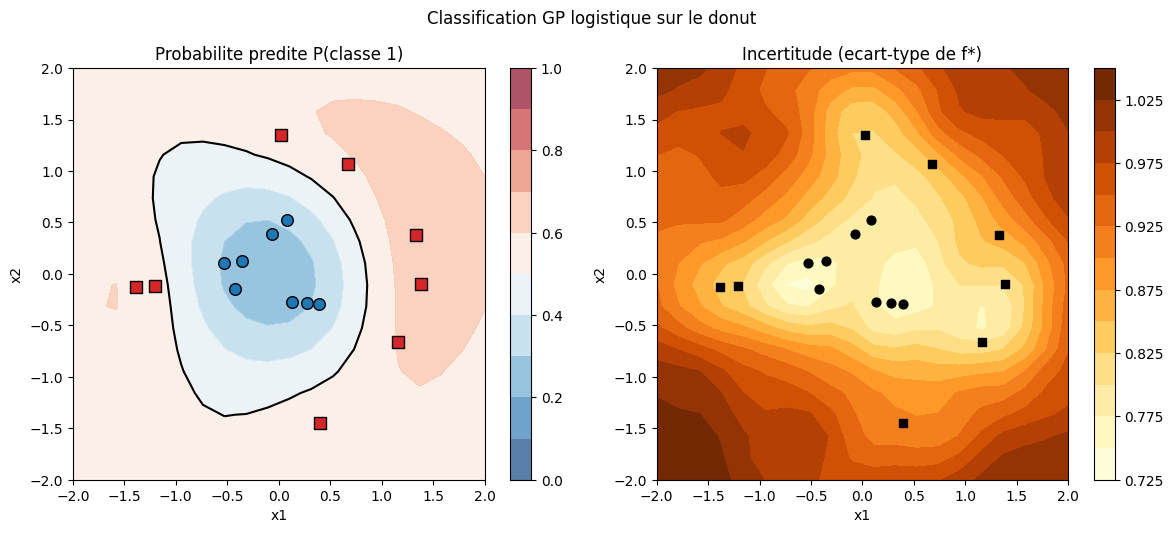

La frontiere (ligne noire, P=0.5) suit l'anneau du donut : non lineaire.
L'incertitude est maximale entre les deux classes (zone d'indetermination).


In [7]:
# Grille de prediction pour visualiser la frontiere de decision.
grid_1d = np.linspace(-2, 2, 20)
G1, G2 = np.meshgrid(grid_1d, grid_1d)
X_grid = np.column_stack([G1.ravel(), G2.ravel()])

# Predictions : f* conditionnel sur la grille, via sample_posterior_predictive.
# On re-entre dans le modele pour definir la variable conditionnelle f_grid.
with gp_model:
    f_grid_var = gp.conditional("f_grid", Xnew=X_grid)
    ppc = pm.sample_posterior_predictive(idata, var_names=["f_grid"], random_seed=42, progressbar=False)
f_grid_samples = ppc.posterior_predictive["f_grid"].values.reshape(-1, X_grid.shape[0])
p_grid = 1 / (1 + np.exp(-f_grid_samples.mean(axis=0)))  # sigmoid(f*)
sig_grid = f_grid_samples.std(axis=0)

P = p_grid.reshape(G1.shape)
S = sig_grid.reshape(G1.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Frontiere de decision (probabilite de la classe 1).
cf = axes[0].contourf(G1, G2, P, levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.7)
axes[0].contour(G1, G2, P, levels=[0.5], colors="k", linewidths=1.5)
axes[0].scatter(X_donut[y_donut == 0, 0], X_donut[y_donut == 0, 1], c="C0", s=70, edgecolors="k", zorder=3)
axes[0].scatter(X_donut[y_donut == 1, 0], X_donut[y_donut == 1, 1], c="C3", s=70, marker="s", edgecolors="k", zorder=3)
axes[0].set_title("Probabilite predite P(classe 1)")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2"); axes[0].set_aspect("equal")
fig.colorbar(cf, ax=axes[0])
# Incertitude (ecart-type de f*).
cs = axes[1].contourf(G1, G2, S, levels=12, cmap="YlOrBr")
axes[1].scatter(X_donut[y_donut == 0, 0], X_donut[y_donut == 0, 1], c="k", s=40, zorder=3)
axes[1].scatter(X_donut[y_donut == 1, 0], X_donut[y_donut == 1, 1], c="k", s=40, marker="s", zorder=3)
axes[1].set_title("Incertitude (ecart-type de f*)")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].set_aspect("equal")
fig.colorbar(cs, ax=axes[1])
fig.suptitle("Classification GP logistique sur le donut", y=1.01)
plt.tight_layout()
plt.show()
print("La frontiere (ligne noire, P=0.5) suit l'anneau du donut : non lineaire.")
print("L'incertitude est maximale entre les deux classes (zone d'indetermination).")


### Accuracy et predictions sur points test

On verifie l'accuracy sur le training set et on predit en quelques points test : au centre (doit etre classe 0), a mi-rayon (incertain), sur l'anneau (classe 1).

In [8]:
# Accuracy sur le training set (f aux points d'observation = variable latente echantillonnee).
f_train_samples = idata.posterior["f"].values.reshape(-1, X_donut.shape[0])
p_train = 1 / (1 + np.exp(-f_train_samples.mean(axis=0)))
pred_train = (p_train > 0.5).astype(int)
acc = (pred_train == y_donut).mean()
print(f"Exactitude training : {int(acc * len(y_donut))}/{len(y_donut)} = {100 * acc:.1f}%")

# Points test : centre (0), mi-rayon (0.9), anneau (1.3,0), anneau haut (0,1.4).
test_points = np.array([[0.0, 0.0], [0.9, 0.0], [1.3, 0.0], [0.0, 1.4]])
with gp_model:
    f_test_var = gp.conditional("f_test", Xnew=test_points)
    ppc_test = pm.sample_posterior_predictive(idata, var_names=["f_test"], random_seed=42, progressbar=False)
f_test_samples = ppc_test.posterior_predictive["f_test"].values.reshape(-1, test_points.shape[0])
p_test = 1 / (1 + np.exp(-f_test_samples.mean(axis=0)))
print("\n=== Predictions sur points test ===")
for tp, p in zip(test_points, p_test):
    print(f"  x={tp} : P(classe 1) = {p:.2f} -> classe {int(p > 0.5)}")
print("\nLecture : centre -> classe 0, anneau -> classe 1, mi-rayon -> incertain.")


Exactitude training : 16/16 = 100.0%


Sampling: [f_test]



=== Predictions sur points test ===
  x=[0. 0.] : P(classe 1) = 0.23 -> classe 0
  x=[0.9 0. ] : P(classe 1) = 0.52 -> classe 1
  x=[1.3 0. ] : P(classe 1) = 0.64 -> classe 1
  x=[0.  1.4] : P(classe 1) = 0.57 -> classe 1

Lecture : centre -> classe 0, anneau -> classe 1, mi-rayon -> incertain.


## 5. Effet de la longueur de corrélation

La longueur de corrélation $\ell$ contrôle la **souplesse** de la frontière :

- $\ell$ **petit** ($\ll 1$) : fonctions très wiggly, frontière fragmentee — risque de **sur-apprentissage** (la section 1, panneau `ls=0.2`, l'illustre sur les tirages du prior).
- $\ell$ **grand** ($\gg 1$) : fonctions très lisses, frontière quasi-linéaire — risque de **sous-apprentissage** (panneau `ls=5.0` de la section 1).
- $\ell$ **apris** : le prior `LogNormal` + NUTS laisse les données choisir le $\ell$ optimal (moyenne posterieure affichée après l'inference ci-dessus).

C'est l'un des avantages du GP **bayesien** sur un noyau a hyperparamètre fixe : l'incertitude sur $\ell$ est propagee dans les predictions, et le modèle peut desactiver de lui-même les echelles de bruit inutiles (Automatic Relevance Determination, cf. [PyMC-10](PyMC-10-Model-Selection.ipynb)). L'exercice 3 ci-dessous invite a verifier empiriquement l'effet d'un prior concentré sur $\ell$.

## 6. Synthese

| Aspect | Infer.NET (Infer-16) | PyMC (ce notebook) |
|--------|----------------------|---------------------|
| API | `SparseGP`, `Variable.FunctionEvaluate` | `pm.gp.Latent`, `gp.prior` |
| Inference | EP (Expectation Propagation) | NUTS (MCMC) |
| Likelihood | `GaussianFromMeanAndVariance > 0` (**probit** : $p=\Phi(f)$) | `Bernoulli(logit_p=f)` (**logit** : $p=\sigma(f)$) |
| Noyau | `SquaredExponential` | `pm.gp.cov.ExpQuad` |
| Hyperparametre ls | fixe | appris (`LogNormal` prior) |

**Points cles** :
- Le GP est une **distribution sur des fonctions** — il modèle directement la frontière de decision, pas une parametrisation fixe.
- La **longueur de corrélation** contrôle la souplesse ; l'apprendre (prior + NUTS) est un avantage bayesien.
- Le GP quantifie l'**incertitude** : maximal entre les classes, minimal pres des données.
- Le donut est **non linéairement séparable** : un classifieur linéaire échoue, le GP reussit.

Le paradigme est le même en Infer.NET et PyMC ; seule l'API et la méthode d'inference (EP vs NUTS) différent.

---

## Exercices

> Les exercices sont stubbes (convention C.1) : le notebook s'execute de bout en bout même non complétée. Conservez les `# TODO` et `# Indice`.


## 7. Exercices

Les trois exercices suivants vous font manipuler les leviers du GP bayésien vus ci-dessus : le choix du **noyau** (exercice 1), la **dureté du dataset** (exercice 2) et l'**effet du prior sur la longueur de corrélation** $\ell$ (exercice 3, en écho de la section 5). Chaque stub est self-contained : reconstruisez le modèle de la section 3 avec la variation demandée.

### Exercice 1 — Noyau Matern vs RBF

**Objectif** : remplacer le noyau `ExpQuad` (RBF) par un `Matern52` et comparer la frontière de décision. Le Matern est moins lisse : la frontière doit l'être aussi.

**Indices** : `pm.gp.cov.Matern52(input_dim=2, ls=ls)` ; gardez le même prior `LogNormal` sur `ls`. Étapes : (1) reconstruisez le modèle avec le nouveau noyau ; (2) échantillonnez (même `draw`/`tune` qu'en section 3) ; (3) tracez la frontière (section 4) et comparez.

In [9]:
# Exercice 1 : noyau Matern au lieu de RBF.
# Remplacez le noyau ExpQuad (RBF) par un noyau Matern (pm.gp.cov.Matern52) et comparez
# la frontière de décision. Le Matern est moins lisse — la frontière devrait l'être aussi.
# Indice : pm.gp.cov.Matern52(input_dim=2, ls=ls). Gardez le même prior LogNormal sur ls.
# Étape 1 : reconstruisez le modèle avec le nouveau noyau.
# Étape 2 : échantillonnez (même draw/tune que la section 3).
# Étape 3 : tracez la frontière (section 4) et comparez.

matern_result = None  # TODO étudiant : idata + prédictions du modèle Matern
print("Exercice 1 à compléter : comparer Matern52 vs ExpQuad.")

Exercice 1 à compléter : comparer Matern52 vs ExpQuad.


### Exercice 2 — Deux anneaux entrelacés (two moons)

**Objectif** : construire un dataset où deux demi-anneaux sont entrelacés (style *two moons*) et vérifier que le GP séparateur reste non linéaire.

**Indices** : pour la classe 0, angles dans $[0, \pi]$ ; pour la classe 1, angles dans $[\pi, 2\pi]$, avec un décalage radial. Étapes : (1) générez `X_moons`, `y_moons` (16 points chacun) ; (2) ré-entraînez le GP (section 3) sur ce dataset ; (3) affichez l'accuracy — elle doit rester élevée si le noyau RBF convient.

In [10]:
# Exercice 2 : dataset plus difficile (deux anneaux entrelacés).
# Construisez un dataset où deux demi-anneaux sont entrelacés (style "two moons").
# Indice : pour la classe 0, angles dans [0, pi] ; pour la classe 1, angles dans [pi, 2*pi],
#          avec un décalage radial. Le GP doit toujours séparer (frontière non linéaire).
# Étape 1 : générez X_moons, y_moons (16 points chacun).
# Étape 2 : ré-entraînez le GP (section 3) sur ce dataset.
# Étape 3 : affichez l'accuracy. Doit rester élevée si le noyau RBF convient.

moons_result = None  # TODO étudiant : dataset + modèle sur two-moons
print("Exercice 2 à compléter : GP sur deux anneaux entrelacés (two moons).")

Exercice 2 à compléter : GP sur deux anneaux entrelacés (two moons).


### Exercice 3 — Effet du prior sur la longueur de corrélation

**Objectif** : mesurer comment un prior *très concentré* sur une grande longueur $\ell$ force le GP vers un modèle quasi linéaire (sous-apprentissage). C'est la vérification empirique promise en section 5.

**Indices** : passez de `pm.LogNormal("ls", mu=0.0, ...)` à `mu=2.0, sigma=0.1`. Étapes : (1) ré-entraînez avec ce prior concentré grand ; (2) comparez la frontière (qui doit devenir quasi-linéaire) et l'accuracy. **Question** : que se passe-t-il avec un prior concentré *petit* (`mu=-1.5`) ?

In [11]:
# Exercice 3 : effet du prior sur ls.
# Si on met un prior très concentré sur une grande longueur (ls ~ LogNormal(2.0, 0.1)),
# le GP devient presque linéaire (sous-apprentissage). Vérifiez-le.
# Indice : changez mu de 0.0 à 2.0 dans pm.LogNormal("ls", mu=2.0, sigma=0.1).
# Étape 1 : ré-entraînez avec ce prior concentré grand.
# Étape 2 : comparez la frontière (qui doit devenir quasi-linéaire) et l'accuracy.
# Question : que se passe-t-il avec un prior concentré petit (mu=-1.5) ?

prior_ls_result = None  # TODO étudiant : modèle avec prior concentré grand sur ls
print("Exercice 3 à compléter : effet du prior sur la longueur de corrélation.")

Exercice 3 à compléter : effet du prior sur la longueur de corrélation.


---

## Pour aller plus loin

- **Regression GP** (target réel au lieu de classe) : remplacez `Bernoulli` par `Normal` et utilisez `pm.gp.Marginal` (conjugue, plus rapide).
- **Sparse GP** : sur de grands datasets ($N > 1000$), la factorisation $O(N^3)$ devient prohibitive. PyMC fournit `pm.gp.MarginalSparse` (inducing points) et `pm.gp.HSGP` (approximation Hilbert) pour $O(NM^2)$.
- **HSGP** : voir Ruitort-Mayol et al. (2023), implemente dans PyMC comme `pm.gp.HSGP` — la méthode SOTA pour les GP a grande échelle.

**Navigation** : [Index](../README.md) | [<< PyMC-15](PyMC-15-Recommenders.ipynb) | [PyMC-17 >>](PyMC-17-Kalman-Filter.ipynb)
